# **Final Model**

*Same architecture and cleaning like my improved model, but with the most recent datasets I have*

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pickle

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import sys
sys.path.insert(0, '../..')

from modeling.dataset import CarPriceDataset
from modeling.model import MLPCarPriceRegressionNet_V1, MLPCarPriceRegressionNet_V2
from modeling.train import train_model
from modeling.test import test_model
from modeling.plots_and_metrics import train_plot, train_metrics, test_plot, test_metrics, test_show_extreme_cases
from modeling.plots_and_metrics import plot_outlier_years, plot_outlier_km, plot_outlier_price, plot_outlier_by_manufacturer, plot_outlier_by_kw

from preprocessing.preprocess import PreProcessor
from preprocessing.clean import Cleaner
from preprocessing.impute import Imputer
from preprocessing.engineer import Engineer 

## **Cleaning & Imputing**

*With latest datasets, focusing on the range 2M - 50M like in the improved model*

In [2]:
FILENAME = 'car_details_174722_20250916.csv'
MODEL_NAME = 'market_model'
FILENAME_DATA = 'car_data_174722_20250916.csv'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

df = pd.read_csv(f'../../data/raw/{FILENAME}')

cleaner = Cleaner(price_lower=2_000_000, price_upper = 50_000_000, year_lower = 2010, year_upper = None)
imputer = Imputer()
engineer = Engineer()

df = cleaner.clean(df)
summary = cleaner.get_summary()
display(summary)

df = imputer.impute(df)
summary = imputer.get_summary()
display(summary)

df = engineer.transform(df)
summary = engineer.get_summary()
display(summary)

df.to_csv(f'../../data/clean/{FILENAME}', index=False)

,Feature,Length Before,Length After,Dropped
0,Price,174722,120026,54696
1,Year,120026,108244,11782
2,Manufacturer/Model,108244,108121,123
3,Kilometers,108121,108099,22
4,Fuel Type,108099,108099,0
5,KW/LE,108099,106919,1180
6,Condition,106919,106919,0
7,Trunk Capacity,106919,106915,4
8,Body Type,106915,106914,1
9,Seats,106914,106912,2


,Feature,Missing Before,Missing After,Imputed
0,Kilometers,2142,0,2142
1,Fuel Type,937,0,937
2,Trunk Capacity,9527,0,9527
3,Seats,1110,0,1110
4,Color,19877,0,19877
5,Engine Capacity,382,0,382
6,Drive Type,2008,0,2008
7,Transmission Type,5102,0,5102
8,Number of Gears,26059,0,26059


,Feature,Unqiue Before,Unqiue After
0,Fuel Type,12,7
1,Transmission Type,9,6
2,Color,76,38


## **Data Prep**

- Model setup, architecture unchanged

- Scaling & Encoding unchanged 

- Splitting involves only putting active listings in the test dataset
    - Still not optimal in a sense that ideally I want to predict all of the active listings but I still do not have enough data for that 

In [3]:


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
car_data = pd.read_csv(f'../../data/raw/{FILENAME_DATA}')
active_ids = car_data[car_data['active'] == True]['id'].values

df_active = df[df['id'].isin(active_ids)]
df_inactive = df[~df['id'].isin(active_ids)]

test_size = int(len(df) * 0.1)
df_test = df_active.sample(n=min(test_size, len(df_active)), random_state=11)

df_remaining = df[~df['id'].isin(df_test['id'])]
df_train, df_val = train_test_split(df_remaining, test_size=0.111, random_state=11)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

df_test.to_csv(f'../../workspace/test_datasets/{FILENAME}', index=False)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


preprocessor = PreProcessor()
preprocessor.fit(df_train)
preprocessor.save(f'../../workspace/config/{MODEL_NAME}.pkl', f'../../workspace/config/{MODEL_NAME}.json')

model = MLPCarPriceRegressionNet_V2(f'../../workspace/config/{MODEL_NAME}.pkl')

X_num_train, X_cat_train, y_train = preprocessor.transform(df_train, is_training = True, include_target = True)
X_num_val, X_cat_val, y_val = preprocessor.transform(df_val, is_training = False, include_target = True)
X_num_test, X_cat_test, y_test = preprocessor.transform(df_test, is_training = False, include_target = True)

train_dataset = CarPriceDataset(X_num_train, X_cat_train, y_train)
val_dataset = CarPriceDataset(X_num_val, X_cat_val, y_val)
test_dataset = CarPriceDataset(X_num_test, X_cat_test, y_test)

batch_size = 64


#drop = (test_size % batch_size) == 1
dataloader_train = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True)
dataloader_val = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = True)
dataloader_test = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False, drop_last=False)


## **Training & Plotting training**

*Unchanged*

Training on: cpu

Epoch [1/150] (LR: 0.000500)
  Train Loss: 6.9270
  Val Loss:   0.1829
  Val MAPE:   29.83%

Epoch [2/150] (LR: 0.000500)
  Train Loss: 0.6687
  Val Loss:   0.0887
  Val MAPE:   26.46%

Epoch [3/150] (LR: 0.000500)
  Train Loss: 0.4091
  Val Loss:   0.1312
  Val MAPE:   24.55%
  Early stopping counter: 1/40

Epoch [4/150] (LR: 0.000500)
  Train Loss: 0.2703
  Val Loss:   0.0824
  Val MAPE:   26.20%

Epoch [5/150] (LR: 0.000500)
  Train Loss: 0.1989
  Val Loss:   0.0386
  Val MAPE:   15.58%

Epoch [6/150] (LR: 0.000500)
  Train Loss: 0.1391
  Val Loss:   0.0351
  Val MAPE:   13.95%

Epoch [7/150] (LR: 0.000500)
  Train Loss: 0.0947
  Val Loss:   0.0321
  Val MAPE:   14.23%

Epoch [8/150] (LR: 0.000500)
  Train Loss: 0.0641
  Val Loss:   0.0331
  Val MAPE:   15.30%
  Early stopping counter: 1/40

Epoch [9/150] (LR: 0.000500)
  Train Loss: 0.0466
  Val Loss:   0.0281
  Val MAPE:   12.50%

Epoch [10/150] (LR: 0.000500)
  Train Loss: 0.0380
  Val Loss:   0.0294
  Val MAPE:

Metric,Value
BEST EPOCH,111.000000
BEST VAL LOSS,0.018537


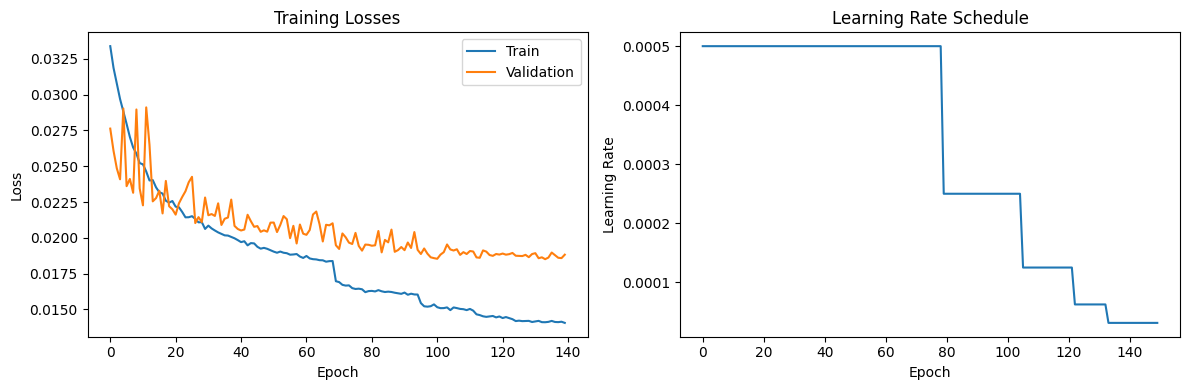

In [4]:
train = True

if train == True:
    history, model = train_model(
        model=model,
        train_loader=dataloader_train,
        val_loader=dataloader_val,
        epochs=150,
        learning_rate=0.0005,
        learning_rate_decay_factor=0.5
    )
    with open(f'../../workspace/train_histories/{MODEL_NAME}.pkl', 'wb') as f:
        pickle.dump(history, f)
    torch.save(model.state_dict(), f'../../workspace/models/{MODEL_NAME}.pt')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

with open(f'../../workspace/train_histories/{MODEL_NAME}.pkl', 'rb') as f:
    history = pickle.load(f)

display(train_metrics(history=history).style.hide(axis=0))
train_plot(history=history, skip_first_x = 10)

## **Testing & Plotting**

*Unchanged*

**Plan:**

    - Displaying the most undervalued cars in another clean Notebook: evalute_market_model

Metric,Value,Description
MAE,1.04M Ft,Average absolute error
RMSE,1.90M Ft,Root mean squared error ~ penalizes outliers more
Mean APE,10.63%,Mean absolute percentage error ~ %
Median APE,8.13%,Median absolute percentage error ~ %
Within 10%,58.71%,Predictions with < 10% error
Within 20%,85.93%,Predictions with < 20% error
Within 30%,95.68%,Predictions with < 30% error


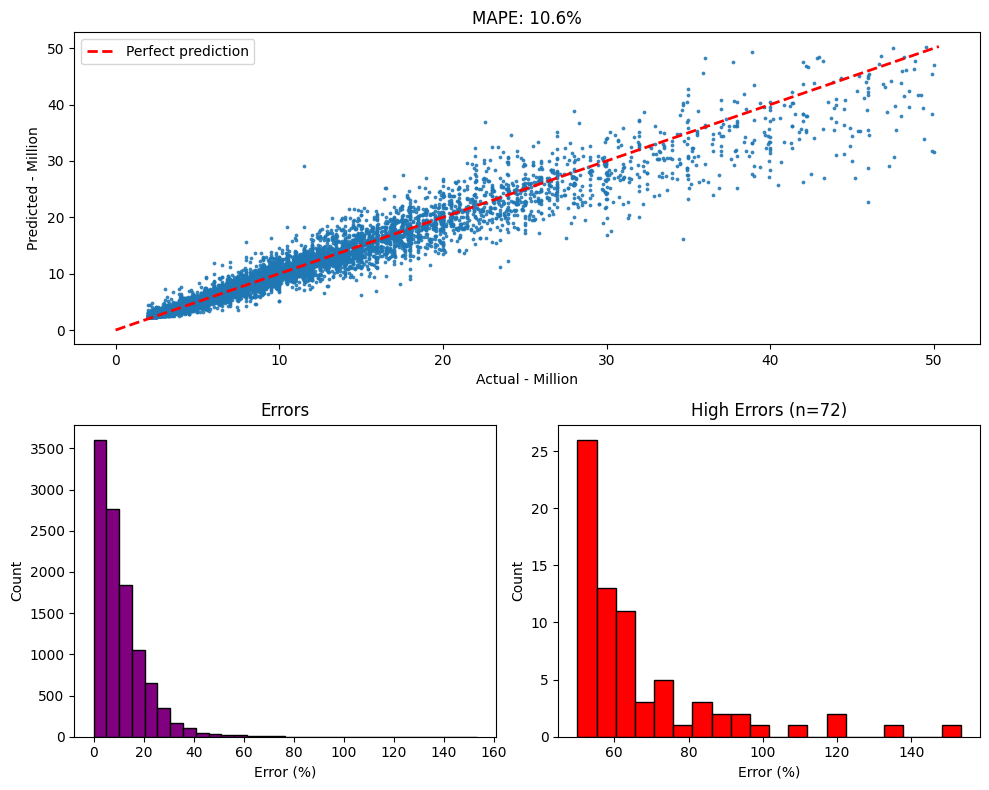

,price,predicted_price,percent_error,manufacturer,model,year,kw,kilometers
2032,11490000.0,29104664.0,153.304108,MERCEDES-BENZ,GLE-OSZTÁLY,2018.08,190.0,137200.0
3550,3050000.0,7206877.0,136.291016,MERCEDES-BENZ,E-OSZTÁLY E 350,2012.42,265.0,307000.0
7067,2000000.0,4439638.0,121.981850,FORD,MUSTANG,2011.00,224.0,243895.0
5711,2200000.0,4802793.0,118.308723,BMW,X SOROZAT X3,2011.58,225.0,290000.0
9205,2090000.0,4364601.5,108.832588,VOLKSWAGEN,TOURAN,2015.83,110.0,200000.0
9077,5999999.0,11959803.0,99.330032,PEUGEOT,208,2021.83,100.0,43300.0
1639,8000000.0,15663817.0,95.797783,JEEP,CHEROKEE GRAND CHEROKEE,2014.00,344.0,58000.0
5349,3490000.0,6738349.5,93.075928,INFINITI,QX QX70,2017.08,175.0,210000.0
2137,4000000.0,7591390.5,89.784775,KIA,CEE'D,2023.25,118.0,81400.0
6162,3900000.0,7356116.0,88.618431,TOYOTA,MR 2,2020.42,103.0,225000.0


In [5]:
model.load_state_dict(torch.load(f'../../workspace/models/{MODEL_NAME}.pt'))

results = test_model(model, dataloader_test)
''' results = {
        'actual_prices' : actual_prices,
        'prediction_prices' : pred_prices,
        'percent_errors' : percent_errors,
        'metrics' : {
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'median_ape': median_ape,
            'within_10': within_10,
            'within_20': within_20,
            'within_30': within_30
        }
    }
'''
display(test_metrics(results = results).style.hide(axis=0))
test_plot(results = results)

with pd.option_context('display.max_colwidth', None):
    display(test_show_extreme_cases(results = results, df_test = df_test,extreme_threshhold=80))


## **Outlier searching**

*Unchanged*

**Plan:**

- If I look at Outliers with a 30% threshhold rather than a 50% its clear that my model can't really predict cars with a lot of km (300k+) on them
    - Possibly introduce another km^2 scared feature or similar
- Same with KW



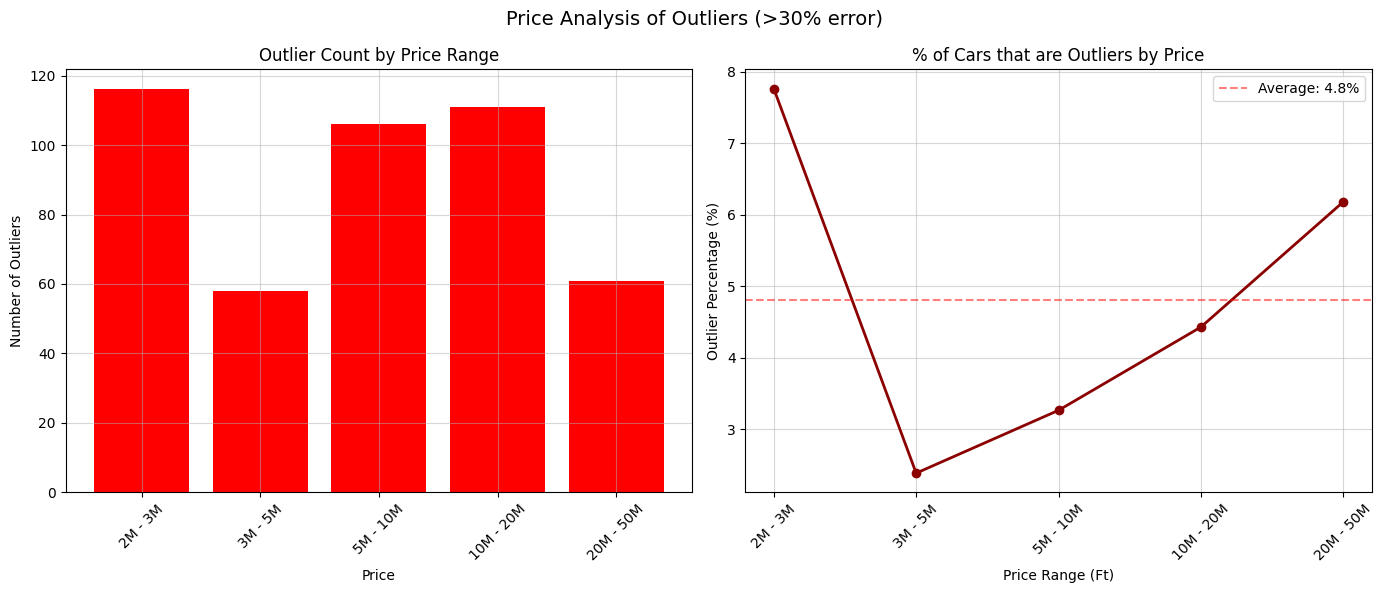

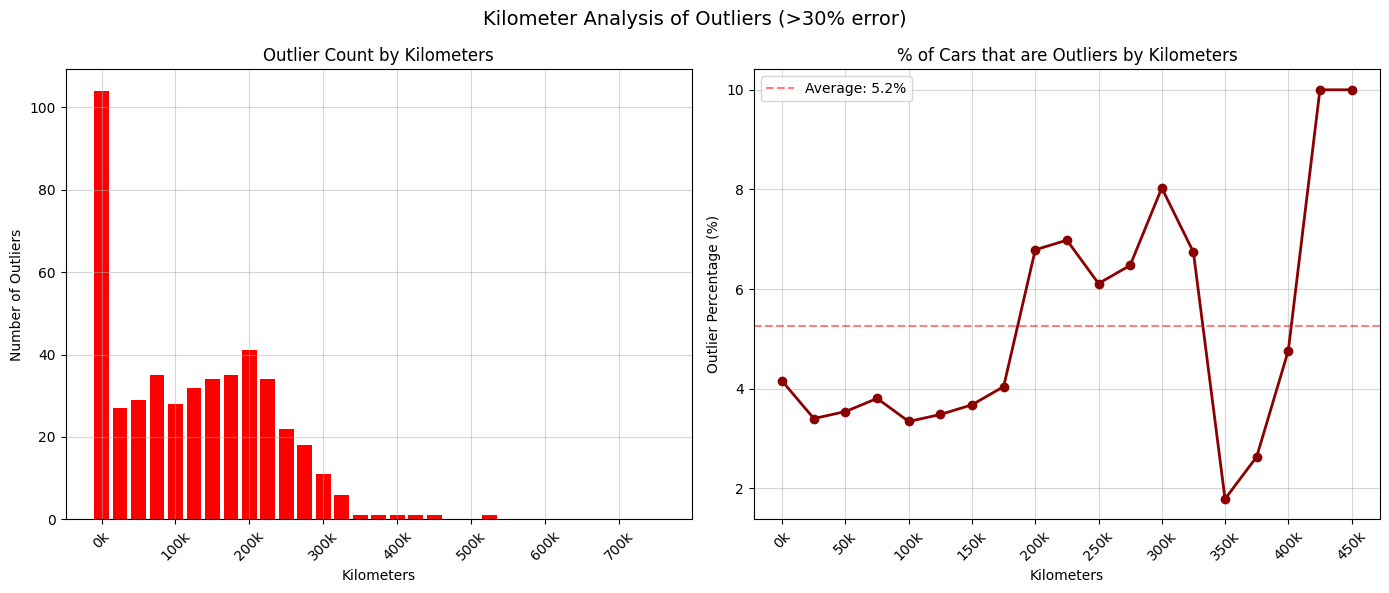

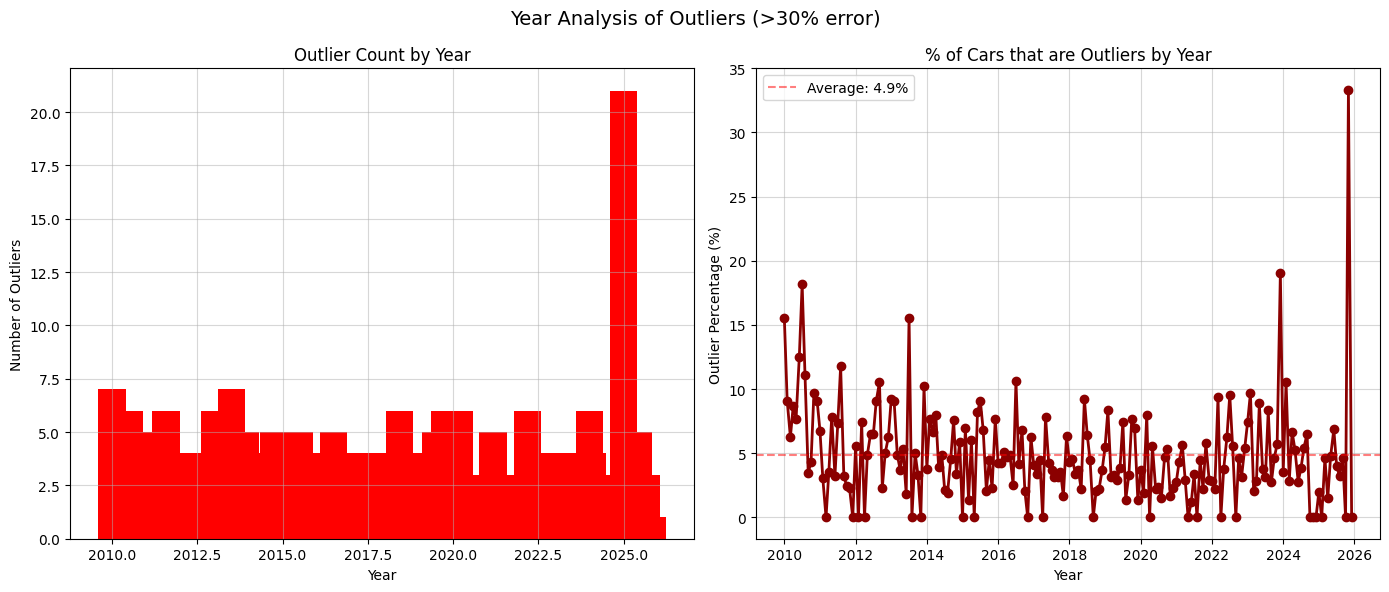

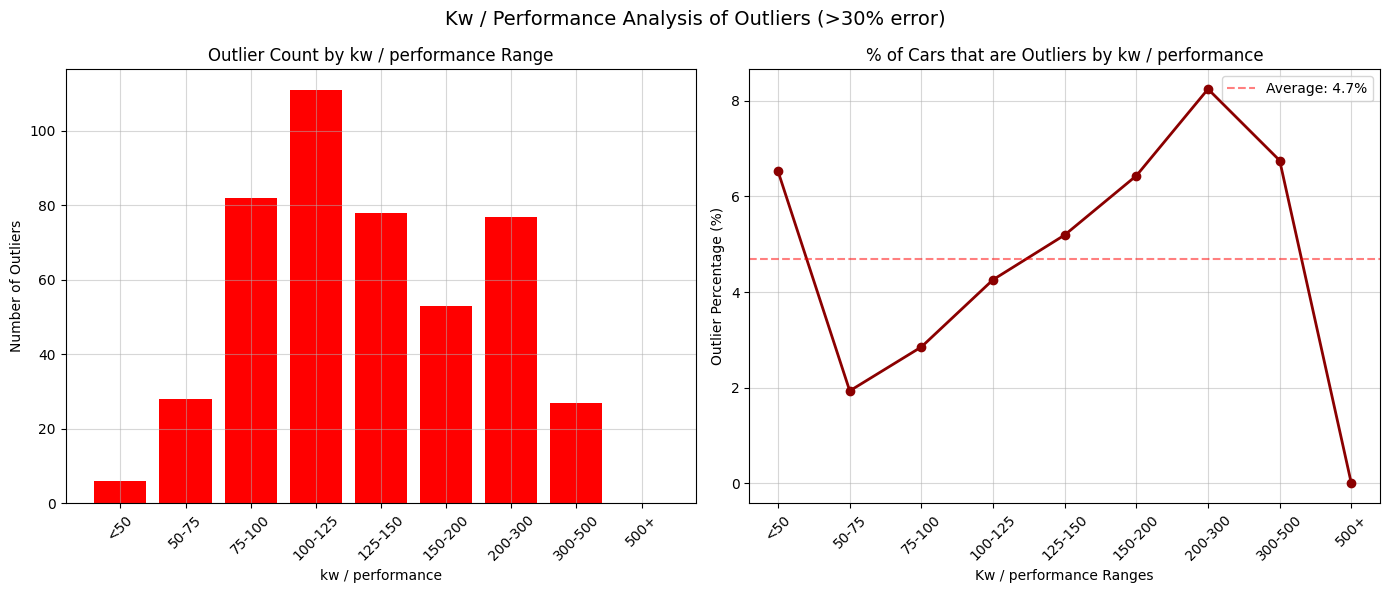

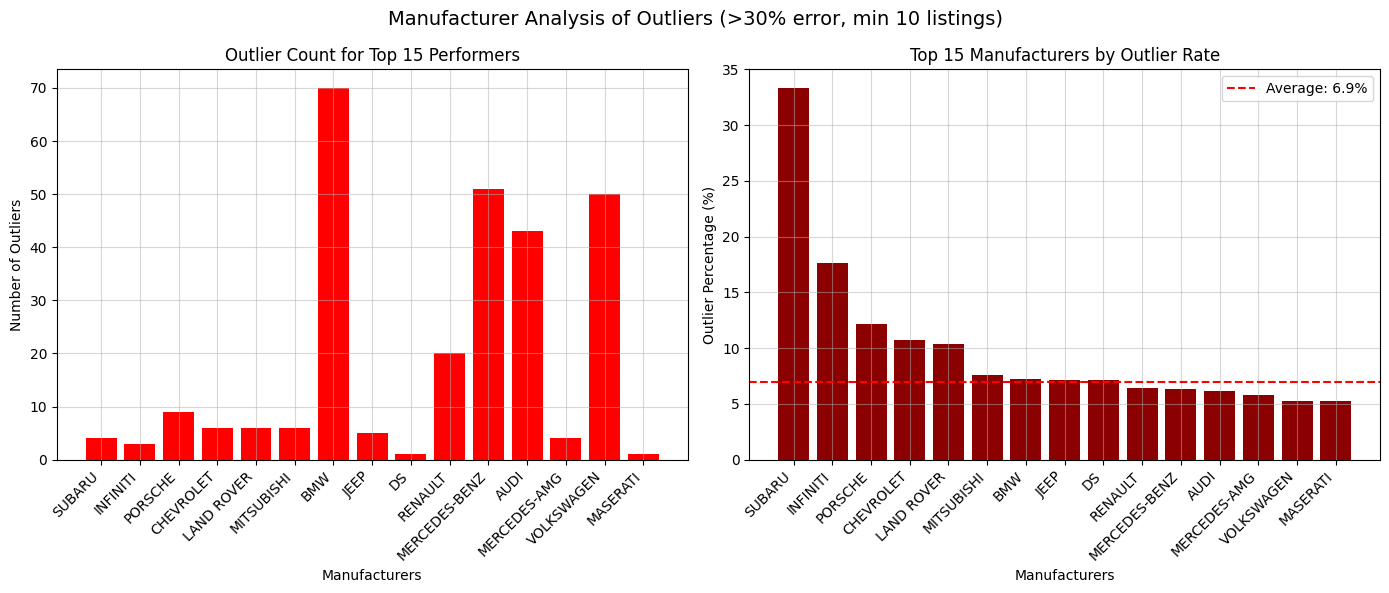

In [6]:
plot_outlier_price(results = results, df_test = df_test, threshold = 30, price_range='2M - 50M')
plot_outlier_km(results = results, df_test = df_test, threshold = 30)
plot_outlier_years(results = results, df_test = df_test, threshold = 30)
plot_outlier_by_kw(results = results, df_test = df_test, threshold = 30)
plot_outlier_by_manufacturer(results = results, df_test = df_test, threshold = 30, min_listings = 10)